In [203]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#### 02 Variable Normal

Ahora vamos a trabajar con una variable normal o gaussiana. Esta queda definida por dos parametros, la media (el centro de los valores) y la varianza (cuanto se alejan los valroes de centro).

Ahora vamos a trabajar con una variable normal o gaussiana. A diferencia de la Bernoulli, que solo podía tomar dos valores, una variable normal es continua y puede tomar cualquier valor dentro de un intervalo.

La distribución normal queda definida por dos parámetros:

-La media $\mu$, que determina el centro de la distribución.

-La varianza $\sigma^2$, que determina cuánto se dispersan los valores alrededor de la media.

Por tanto, modificando $\mu$ desplazamos la distribución hacia un lado u otro, mientras que modificando $\sigma^2$ hacemos que los valores estén más o menos concentrados alrededor de la media.

In [204]:
media = 0
varianza = 1

In [205]:
mu = 0
sigma = 1

# Generamos una muestra
n = 1000
datos = np.random.normal(loc=mu,scale=sigma,size=n)

print(datos[:10])

[ 0.20676095  0.98297251  0.06024137 -1.06194535 -1.23620834  2.5670754
  1.12713252  0.12564418 -1.13681605  0.11569265]


Deberíamos obtener valores cercanos a 0 y 1, pero no exactamente, porque estamos trabajando con una muestra finita.

In [206]:
print("Media:", datos.mean())
print("Varianza:", datos.var())

Media: -0.010708954058775737
Varianza: 0.9931588135041435


Una forma cómoda de representar una variable continua es mediante un histograma. El histograma agrupa los valores de la muestra en intervalos y muestra con qué frecuencia aparecen.

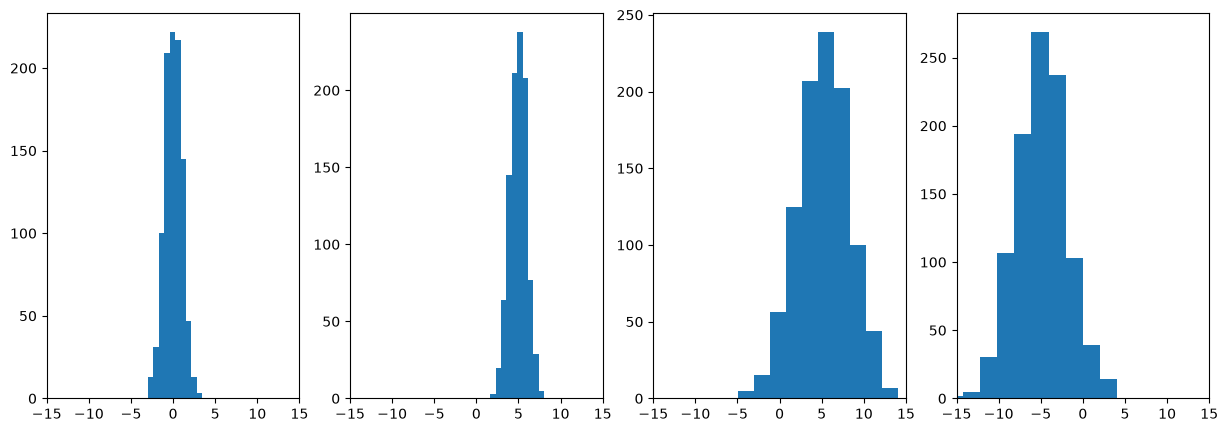

In [207]:
media = [0, 5, 5, -5]
std_dev = [1 , 1, 3 , 3]
n = 1000

datos = []
for mu, sigma in zip(media, std_dev):
    datos.append(np.random.normal(loc=mu,scale=sigma,size=n))

fig, axes = plt.subplots(1, len(media), figsize=(15,5))

for i, ax in enumerate(axes.flatten()):
    ax.hist(datos[i])

    ax.set_xlim(-15,15)


Si tenemos una muestra suficientemente grande, el histograma normalizado se aproxima a la función de densidad de probabilidad (PDF) de la distribución de la que proceden los datos.

Por ejemplo, vamos a variar el tamaño de la muestra y comparar el histograma de los datos con la función de densidad teórica de una distribución normal con media $\mu=0$ y varianza $\sigma^2=1$.

Al aumentar el tamaño de la muestra, esperamos que el histograma represente cada vez mejor la distribución de la que proceden los datos.

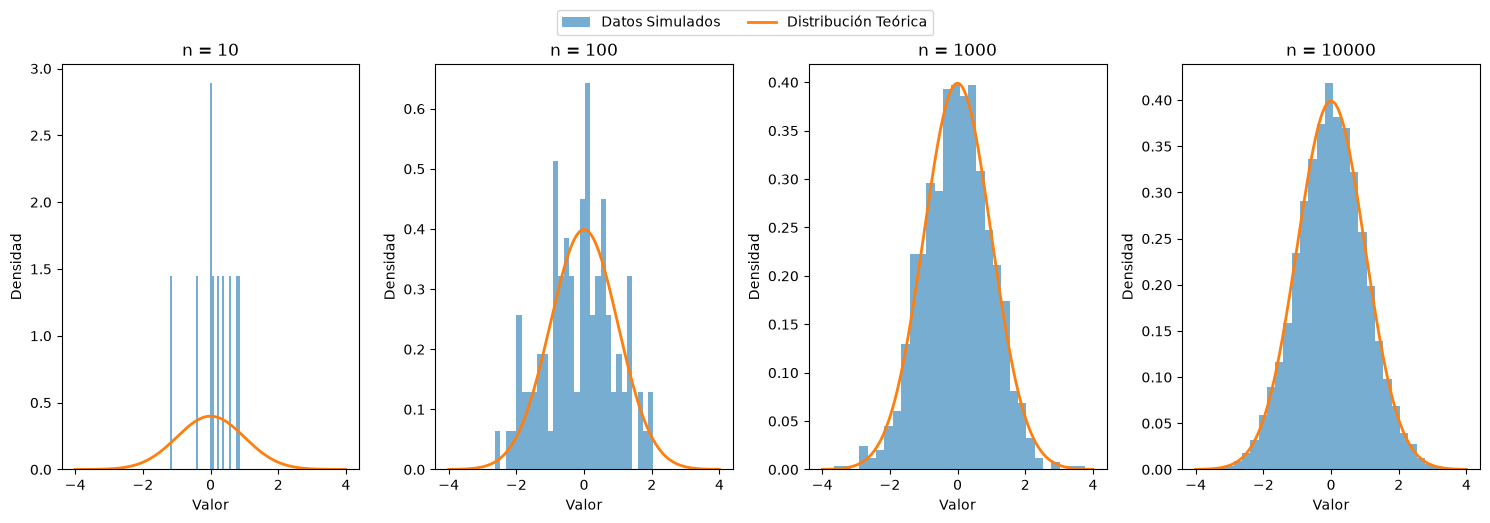

In [208]:
# Parámetros de la distribución
mu = 0
sigma = 1

# Tamaños de muestra
tamanos = [10, 100, 1000, 10000]

# Valores para representar la PDF teórica
x = np.linspace(-4, 4, 500)
pdf = norm.pdf(x, loc=mu, scale=sigma)  # scale es la desviación estándar σ, no la varianza σ².
                                        # En este caso σ = 1, por lo que coinciden.

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, n in zip(axes.flat, tamanos):

    # Generamos la muestra
    datos = np.random.normal(
        loc=mu,
        scale=sigma,
        size=n
    )

    # Histograma normalizado
    ax.hist(datos, bins=30, density=True, alpha=0.6, label='Datos Simulados')

    # PDF teórica
    ax.plot(x, pdf, linewidth=2, label = 'Distribución Teórica')

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")

# Leyenda común
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.05)
)


plt.tight_layout()
plt.show()

Ahora tenemos dos parámetros, la media $\mu$ y la desviación estándar $\sigma$. Vamos a ver cómo varía su estimación cuando trabajamos con muestras de un número finito de datos.

De nuevo, podemos utilizar la media de la muestra como estimador de la media de la distribución. Aunque ambas no tienen por qué coincidir exactamente, esperamos que la estimación sea cada vez más precisa a medida que aumenta el tamaño de la muestra.

In [209]:
tamanos = [10,30,50,100,500,1000]
n_muestras = 500

estimaciones_media = []

for n in tamanos:

    medias = []

    for i in range(n_muestras):

        datos = np.random.normal(mu, sigma, n)
        medias.append(datos.mean())

    estimaciones_media.append(medias)

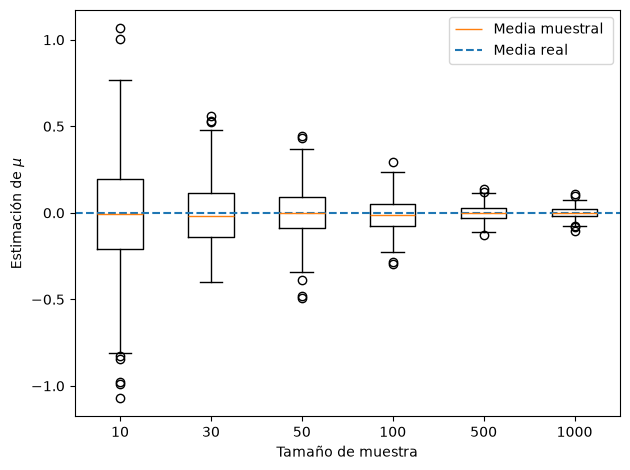

In [210]:
plt.boxplot(estimaciones_media, label='Media muestral ')

plt.axhline(mu, linestyle="--", label="Media real")

plt.xlabel("Tamaño de muestra")
plt.xticks(
    range(1, len(tamanos) + 1),
    tamanos
)
plt.ylabel(r"Estimación de $\mu$")
plt.legend()

plt.tight_layout()
plt.show()

Ahora probamos con la desviación estándar o la varianza.

¿Es la varianza muestral un buen indicador de la varianza de la población?

Vamos a comprobarlo experimentalmente.

De forma natural, podemos calcular la varianza de los datos utilizando la media muestral y dividiendo entre el número de observaciones (n):

$$
\hat{\sigma}^2 =
\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

In [211]:
tamanos = [10,30,50,100,500,1000]
n_muestras = 500

estimaciones_varianza = []

for n in tamanos:

    varianzas = []

    for i in range(n_muestras):

        datos = np.random.normal(mu, sigma, n)
        varianzas.append(datos.var())

    estimaciones_varianza.append(varianzas)

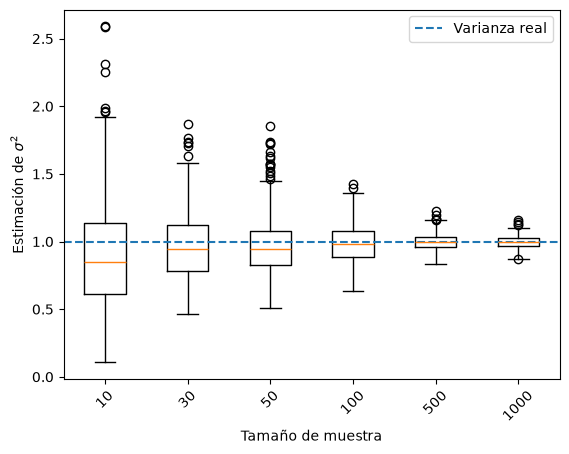

In [212]:
plt.boxplot(estimaciones_varianza)

plt.axhline(sigma**2, linestyle="--", label="Varianza real")

plt.xticks(
    range(1, len(tamanos) + 1),
    tamanos,
    rotation=45
)

plt.xlabel("Tamaño de muestra")
plt.ylabel(r"Estimación de $\sigma^2$")
plt.legend()

plt.show()

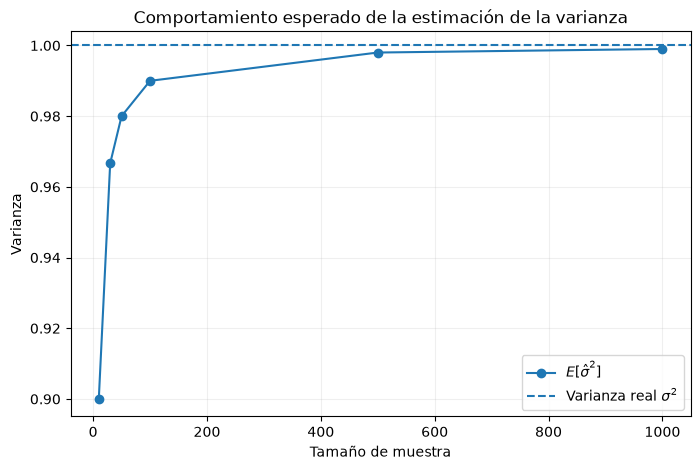

In [213]:
tamanos = [10, 30, 50, 100, 500, 1000]

# Valor esperado de la estimación de la varianza
var_esperada = [(n - 1) / n * sigma**2 for n in tamanos]

plt.figure(figsize=(8, 5))

plt.plot(
    tamanos,
    var_esperada,
    marker="o",
    label=r"$E[\hat{\sigma}^2]$"
)

plt.axhline(
    sigma**2,
    linestyle="--",
    label=r"Varianza real $\sigma^2$"
)

plt.xlabel("Tamaño de muestra")
plt.ylabel(r"Varianza")
plt.title("Comportamiento esperado de la estimación de la varianza")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [214]:
mean_list = []
for i in range(len(estimaciones_media)):
    mean_list.append(np.mean(estimaciones_media[i]))

var_list = []
for i in range(len(estimaciones_varianza)):
    var_list.append(np.mean(estimaciones_varianza[i]))


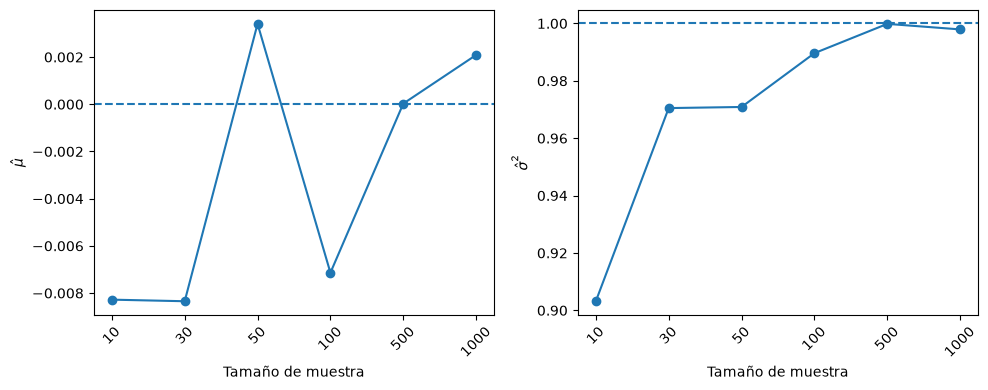

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(mean_list, marker="o")
axes[0].axhline(0, linestyle="--")
axes[0].set_xticks(range(len(tamanos)))
axes[0].set_xticklabels(tamanos, rotation=45)
axes[0].set_xlabel("Tamaño de muestra")
axes[0].set_ylabel(r"$\hat{\mu}$")

axes[1].plot(var_list, marker="o")
axes[1].axhline(1, linestyle="--")
axes[1].set_xticks(range(len(tamanos)))
axes[1].set_xticklabels(tamanos, rotation=45)
axes[1].set_xlabel("Tamaño de muestra")
axes[1].set_ylabel(r"$\hat{\sigma}^2$")

plt.tight_layout()
plt.show()

In [216]:
var_list

[np.float64(0.903177446063839),
 np.float64(0.9704968780635143),
 np.float64(0.9708828302968304),
 np.float64(0.9896363374930229),
 np.float64(0.9998488415400113),
 np.float64(0.9979152273835011)]

In [217]:
mean_list

[np.float64(-0.008278309479611919),
 np.float64(-0.008345615329559077),
 np.float64(0.0034063959510281833),
 np.float64(-0.007137768596581111),
 np.float64(2.8783914907246187e-05),
 np.float64(0.0020891134542517253)]

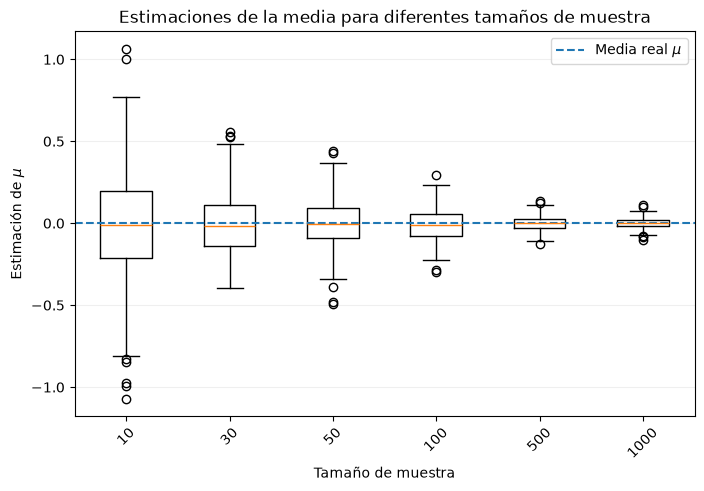

In [218]:
plt.figure(figsize=(8, 5))

plt.boxplot(estimaciones_media)

plt.axhline(
    mu,
    linestyle="--",
    label=r"Media real $\mu$"
)

plt.xticks(
    range(1, len(tamanos) + 1),
    tamanos,
    rotation=45
)

plt.xlabel("Tamaño de muestra")
plt.ylabel(r"Estimación de $\mu$")
plt.title("Estimaciones de la media para diferentes tamaños de muestra")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

Ahora vamos a trabajar con otro estimador de la varianza: la varianza muestral.

La diferencia con el estimador que hemos utilizado hasta ahora es que, en lugar de dividir entre $n$, dividimos entre $n-1$:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

Vamos a repetir la simulación anterior y comprobar qué efecto tiene este cambio sobre nuestras estimaciones.

In [220]:
estimaciones_varianza_muestral = []

for n in tamanos:

    varianzas = []

    for i in range(n_muestras):

        datos = np.random.normal(mu, sigma, n)
        varianzas.append(datos.var(ddof=1))

    estimaciones_varianza_muestral.append(varianzas)

In [221]:
# Ojo 
datos.var()          # divide entre n
datos.var(ddof=1)    # divide entre n-1

np.float64(0.9568072108157206)

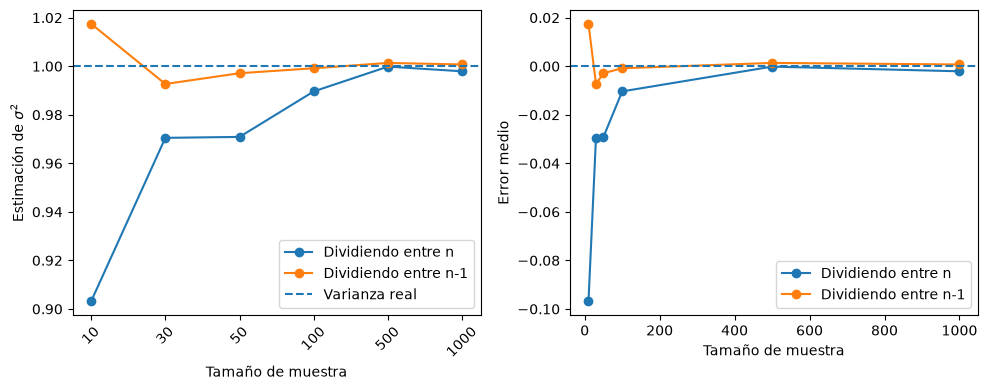

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(
    [np.mean(x) for x in estimaciones_varianza],
    marker="o",
    label="Dividiendo entre n"
)

axes[0].plot(
    [np.mean(x) for x in estimaciones_varianza_muestral],
    marker="o",
    label="Dividiendo entre n-1"
)

axes[0].axhline(sigma**2, linestyle="--", label="Varianza real")

axes[0].set_xticks(range(len(tamanos)))
axes[0].set_xticklabels(tamanos, rotation=45)
axes[0].set_xlabel("Tamaño de muestra")
axes[0].set_ylabel(r"Estimación de $\sigma^2$")
axes[0].legend()


# Diferencia respecto al valor verdadero
axes[1].plot(
    tamanos,
    [np.mean(x) - sigma**2 for x in estimaciones_varianza],
    marker="o",
    label="Dividiendo entre n"
)

axes[1].plot(
    tamanos,
    [np.mean(x) - sigma**2 for x in estimaciones_varianza_muestral],
    marker="o",
    label="Dividiendo entre n-1"
)

axes[1].axhline(0, linestyle="--")

axes[1].set_xlabel("Tamaño de muestra")
axes[1].set_ylabel("Error medio")
axes[1].legend()

plt.tight_layout()
plt.show()